In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

import sys
sys.path.append("/mnt/d/Users/Admin/Projects/dso/learnable_polyphase_sampling/learn_poly_sampling")

from functools import partial
from layers import PolyphaseInvariantDown2D, LPS, get_logits_model
from models.resnet_custom import ResNet18Custom

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"

In [4]:
def get_mask_path(img_path, npy_root, mask_root):
    """
    Map a sample path under npy_noscaling_files/... to its corresponding
    mask path under masks/npy_files/...
    """
    img_path = Path(img_path)
    npy_root = Path(npy_root)
    mask_root = Path(mask_root)
    
    rel_path = img_path.relative_to(npy_root)  # e.g. real/2s1/2s1_real_..._b01.npy
    return mask_root / rel_path

In [5]:
meas_ds = DatasetFolderWithPath(
    os.path.join(workspace, "data/DSO/mstar/npy_noscaling_files/real"),
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

In [6]:
npy_root = os.path.join(workspace, "data/DSO/mstar/npy_noscaling_files")
mask_root = os.path.join(workspace, "data/DSO/mstar/masks/npy_files")

meas_paths = [s[0] for s in meas_ds.samples]
meas_target_cache = {}

for path in tqdm(meas_paths):
    mask_path = get_mask_path(path, npy_root, mask_root)
    mask = np.load(mask_path)
    meas_target_cache[path] = (mask > 0).astype(np.uint8)

100%|████████████████████████████████████████████████████████████████████████████| 13932/13932 [00:58<00:00, 236.86it/s]


In [7]:
precomputed_target_meas_ds = DatasetFolderWithPath(
    os.path.join(workspace, "data/DSO/mstar/npy_noscaling_files/real"),
    extensions=(".npy"),
    transform=transforms.Compose([
        Magnitude(),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=meas_target_cache),
        NumpyToTensor3Channel()
    ]),
    loader=dso_np_file_loader
)

In [8]:
def obtain_mask_from_tiff_flipped(path, values = [65, 67, 193, 195, 225, 227]):
    with TiffFile(path) as tif:
        mask = tif.pages[3].asarray()
    mask = np.fliplr(mask)
    return np.isin(mask, values)

In [9]:
no_aug_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
    extensions=(".tif",),
    transform=transforms.Compose([Magnitude(), LogMapping(c=1000.0), NumpyToTensor3Channel()]),
    loader=dso_tiff_file_loader_fast_flipped
)

synth_paths = [s[0] for s in no_aug_synth_ds.samples]
synth_target_cache = {}

for path in tqdm(synth_paths):
    mask = obtain_mask_from_tiff_flipped(path, values = [193, 195, 225, 227])
    synth_target_cache[path] = mask.astype(np.uint8)

synth_target_cache_cropped = {}
for path, mask in synth_target_cache.items():
    h, w = mask.shape
    t = 128
    top, left = (h - t) // 2, (w - t) // 2
    synth_target_cache_cropped[path] = mask[top:top+t, left:left+t]

100%|██████████████████████████████████████████████████████████████████████████████| 3600/3600 [00:35<00:00, 100.14it/s]


In [10]:
cropped_seg_target_synth_ds = DatasetFolderWithPath(
    "/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26",
    extensions=(".tif",),
    transform=transforms.Compose([
        Magnitude(),
        CenterCrop(128),
        LogMapping(c=1000.0),
        MaskedAugmentation(augmentation=identity, fill=0, mask_cache=synth_target_cache_cropped),
        NumpyToTensor3Channel()
    ]),
    loader=dso_tiff_file_loader_fast_flipped
)

In [11]:
precomputed_target_meas_ds.classes

['2s1',
 'bmp2',
 'brdm_2',
 'btr_60',
 'btr_70',
 'd7',
 't62',
 't72',
 't72_a04',
 't72_a05',
 't72_a07',
 't72_a10',
 't72_a32',
 't72_a62',
 't72_a63',
 't72_a64',
 'zil131',
 'zsu_23_4']

In [12]:
cropped_seg_target_synth_ds.classes

['BRDM2_X3230gz15sqp00',
 'T62_X3230gz15sqp00',
 'ZIL131_X3230gz15sqp00',
 'ZSU234_X3230gz15sqp00',
 'old_ZSU-23-4_X3230gz15sqp00']

In [13]:
train_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(cropped_seg_target_synth_ds, {14, 15, 16}), list(range(281, 351, 1))), 
    exclude_label= 4)

valid_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(precomputed_target_meas_ds, {14, 15, 16}), list(range(10, 80, 1))),
    exclude_label= {0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15})
                          
test_ds = RemappedSubset(
    filter_by_azimuth(filter_by_elev(precomputed_target_meas_ds, {17}), list(range(10, 80, 1))),
    exclude_label= {0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [14]:
dataset_sizes

{'train': 560, 'val': 243, 'test': 234}

In [15]:
train_ds.classes, valid_ds.classes, test_ds.classes

(['BRDM2_X3230gz15sqp00',
  'T62_X3230gz15sqp00',
  'ZIL131_X3230gz15sqp00',
  'ZSU234_X3230gz15sqp00'],
 ['brdm_2', 't62', 'zil131', 'zsu_23_4'],
 ['brdm_2', 't62', 'zil131', 'zsu_23_4'])

In [16]:
test_ds.samples

[('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_010_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_011_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_012_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_013_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_014_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_015_sn_e-71.npy',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_01

In [17]:
test_ds.samples[10]

('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/mstar/npy_noscaling_files/real/brdm_2/brdm_2_real_elevDeg_017_azCenter_020_sn_e-71.npy',
 0)

In [18]:
np.unique(test_ds[10][0][0])

array([0.        , 0.36179855, 0.4194739 , 0.42530125, 0.43629614,
       0.45136526, 0.46060482, 0.47344437, 0.48141202, 0.4889639 ,
       0.4961412 , 0.49960065, 0.50950897, 0.5217459 , 0.53835624,
       0.54094833, 0.54599726, 0.550876  , 0.5532551 , 0.5555957 ,
       0.55789906, 0.5601663 , 0.5623986 , 0.56889606, 0.5730711 ,
       0.57511437, 0.5771292 , 0.5810765 , 0.58491904, 0.5868027 ,
       0.5904981 , 0.592311  , 0.5941015 , 0.5958701 , 0.5976173 ,
       0.60104984, 0.602736  , 0.60605055, 0.6076798 , 0.6108843 ,
       0.6124603 , 0.61401933, 0.6155618 , 0.61708796, 0.6185982 ,
       0.62157226, 0.6230366 , 0.6259217 , 0.627343  , 0.6287505 ,
       0.63014436, 0.63289255, 0.6355895 , 0.6369193 , 0.6382371 ,
       0.639543  , 0.64083713, 0.6433913 , 0.6459012 , 0.6483683 ,
       0.64958626, 0.6507941 , 0.6519919 , 0.65435815, 0.65668637,
       0.65783656, 0.66010994, 0.66123337, 0.6645522 , 0.66564184,
       0.66779673, 0.6720126 , 0.67407537, 0.67509586, 0.67610

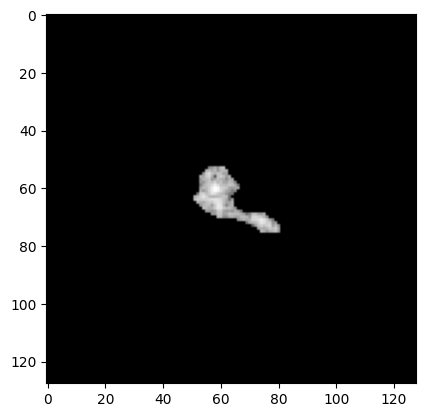

In [19]:
plt.imshow(test_ds[10][0][0].numpy(), cmap='gray', vmin = 0, vmax = 1)

In [20]:
test_ds[10][0][0].numpy().shape

(128, 128)

In [21]:
train_ds.samples

[('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp281f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp281g_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp282f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp282g_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp283f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp283g_X3230gz15sqp00_dispimg_fdf6d9968.tif',
  0),
 ('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp284f_X3230gz15sqp00_d

In [22]:
train_ds.samples[118]

('/mnt/d/Users/Admin/Projects/dso/SAR_ML/data/DSO/MSTAR_sim_jul26/BRDM2_X3230gz15sqp00/BRDM2_asp340f_X3230gz15sqp00_dispimg_fdf6d9968.tif',
 0)

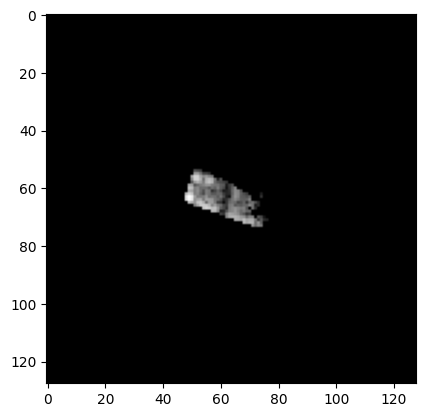

In [23]:
plt.imshow(train_ds[118][0][0].numpy(), cmap='gray', vmin = 0, vmax = 1)

In [24]:
train_ds[118][0][0].numpy().shape

(128, 128)

In [25]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
 
    # Define the loss function and optimizer
    criterion = nn.NLLLoss()

    net_pars, pool_pars = [], []
    for n, p in model.named_parameters():
        if "component_selection" in n and p.requires_grad:
            pool_pars.append(p)
        elif p.requires_grad:
            net_pars.append(p)
            
    optimizer = optim.AdamW([
        {"params": net_pars, "weight_decay": 2e-4},
        {"params": pool_pars, "weight_decay": 0},
    ], lr=3e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max=200, eta_min=3e-7)
    
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.core.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/dso_data/new_data/wo_aug/rn18_seed{seed}_b16_theirmodel.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Epoch 0
First layer mean: 0.000035
train Loss: 0.6388793030 Acc: 0.7267857143
val Loss: 10.1649691288 Acc: 0.2510288066
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.1463351830 Acc: 0.9553571429
val Loss: 2.4749879126 Acc: 0.2716049383
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.0898882111 Acc: 0.9732142857
val Loss: 10.7200453198 Acc: 0.2839506173
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.0856164494 Acc: 0.9589285714
val Loss: 9.8966479157 Acc: 0.2510288066
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.1601175730 Acc: 0.9464285714
val Loss: 10.7611319727 Acc: 0.4855967078
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0431365408 Acc: 0.9875000000
val Loss: 4.9711839027 Acc: 0.2757201646
Epoc

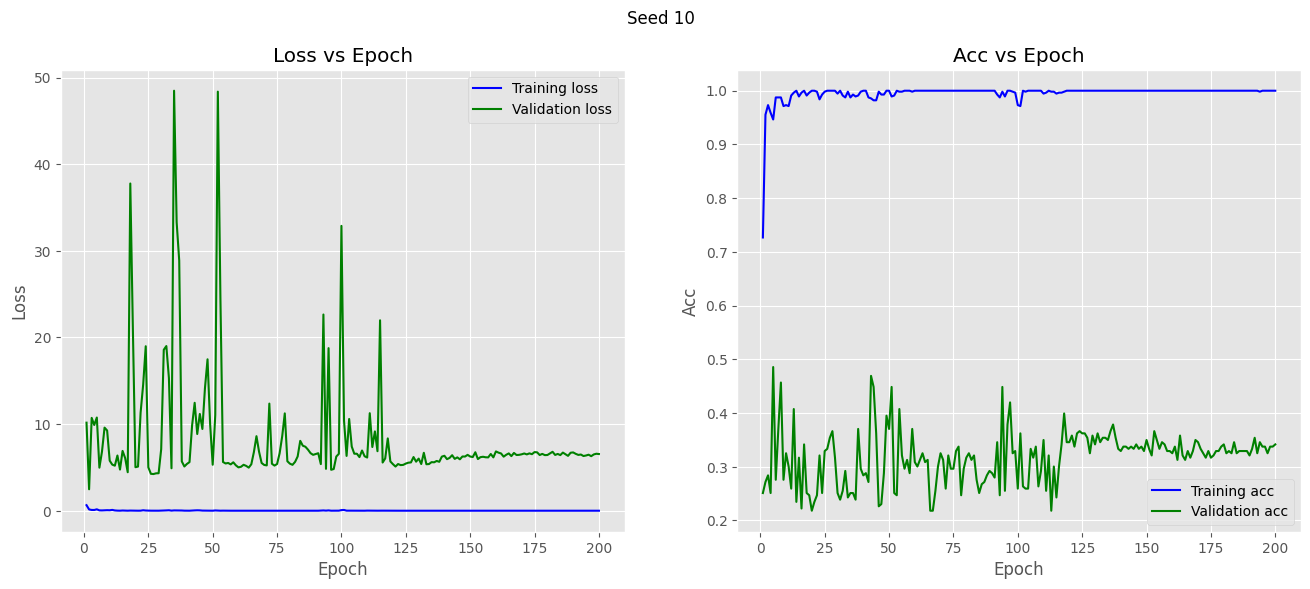

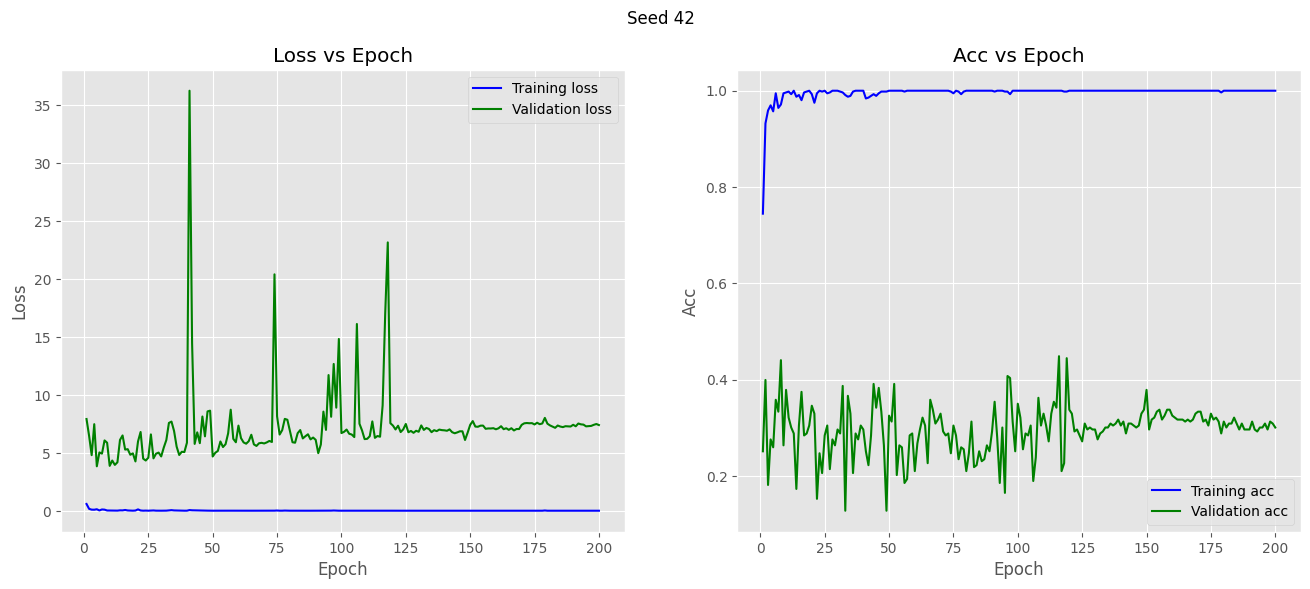

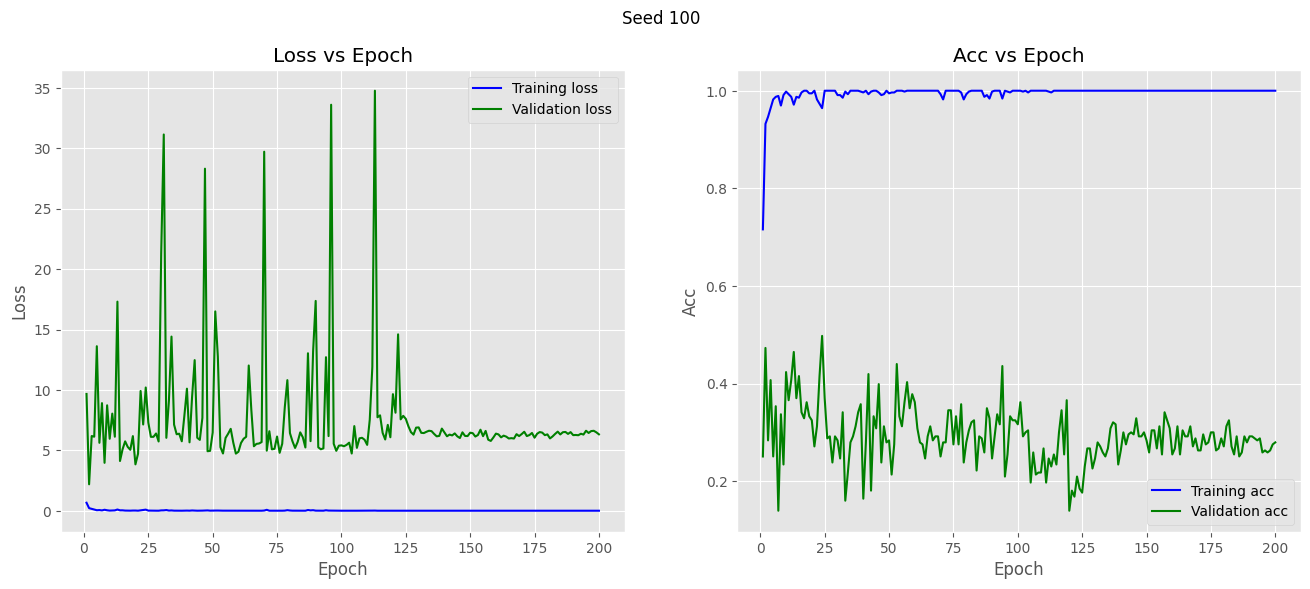

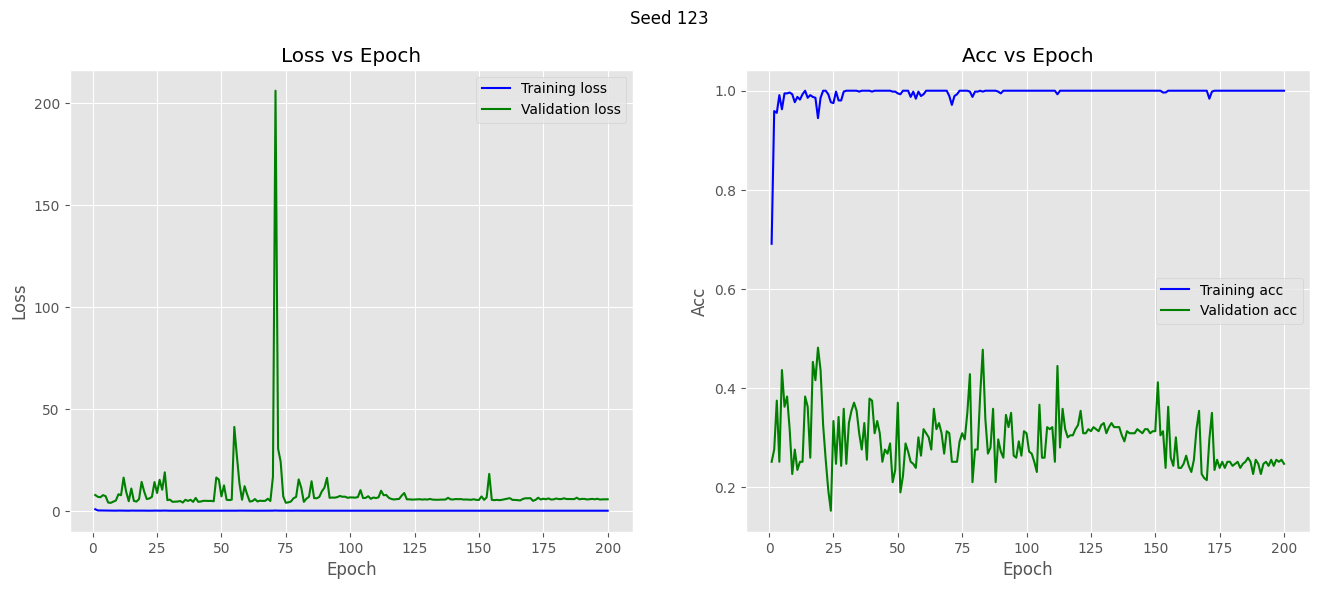

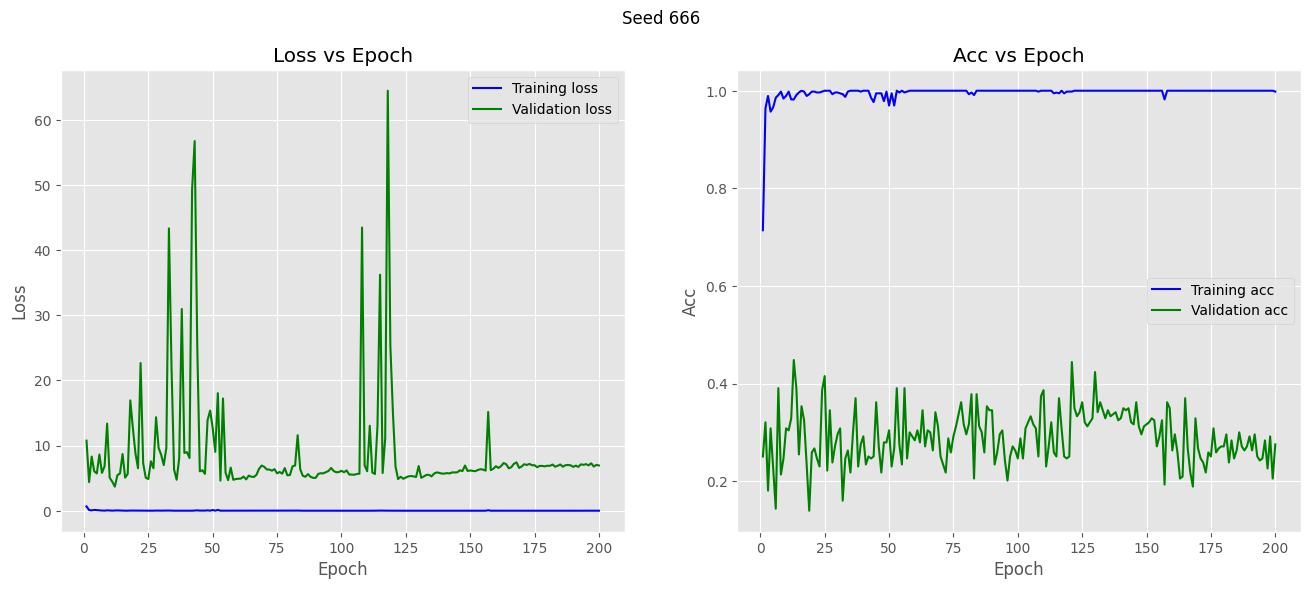

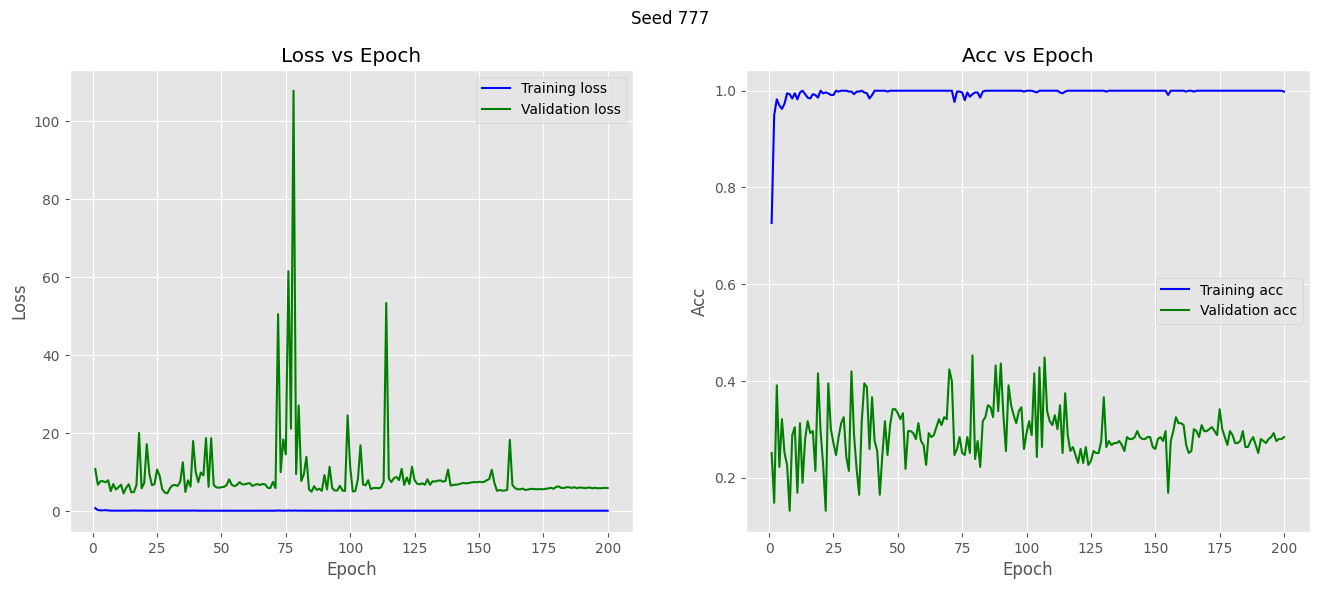

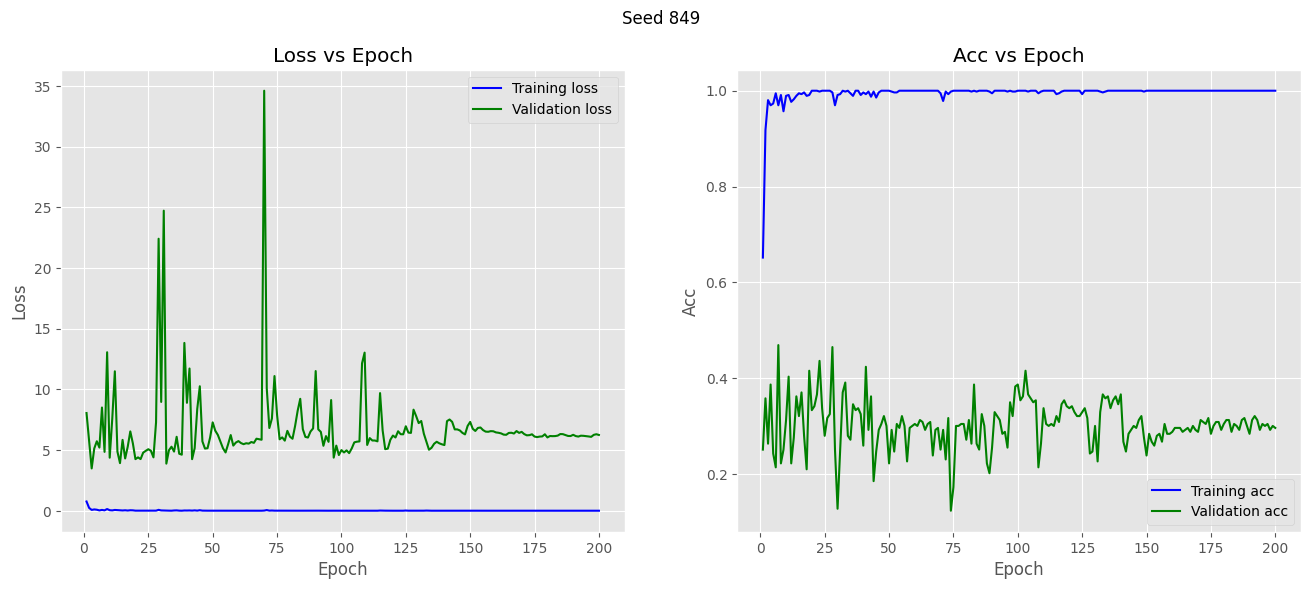

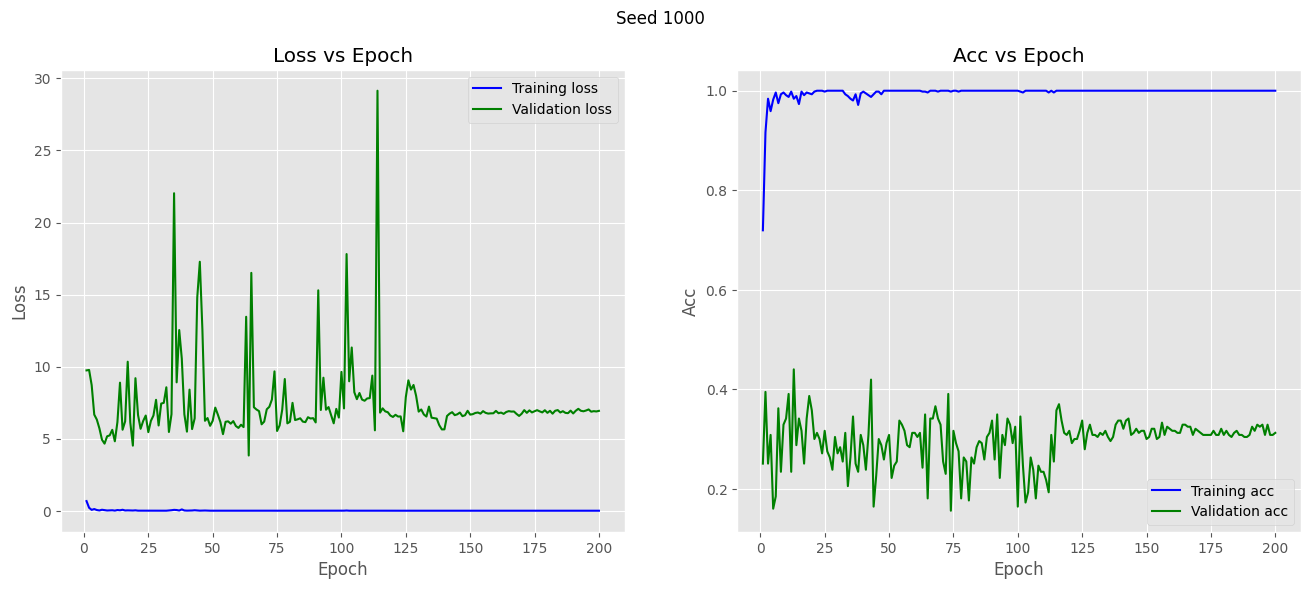

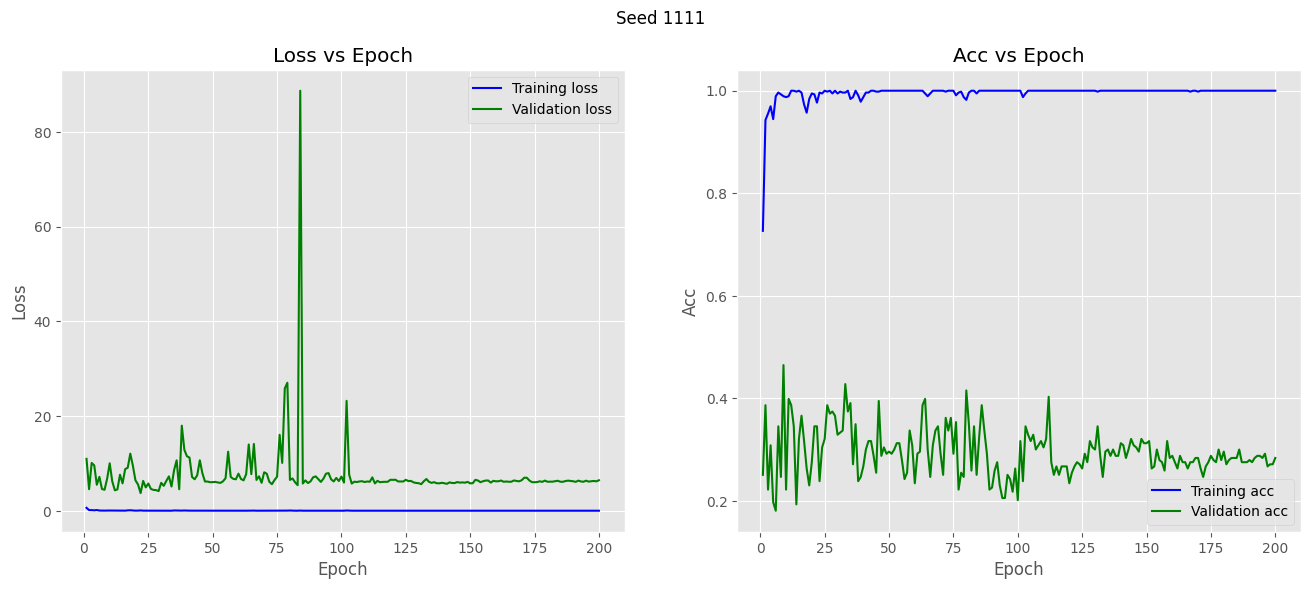

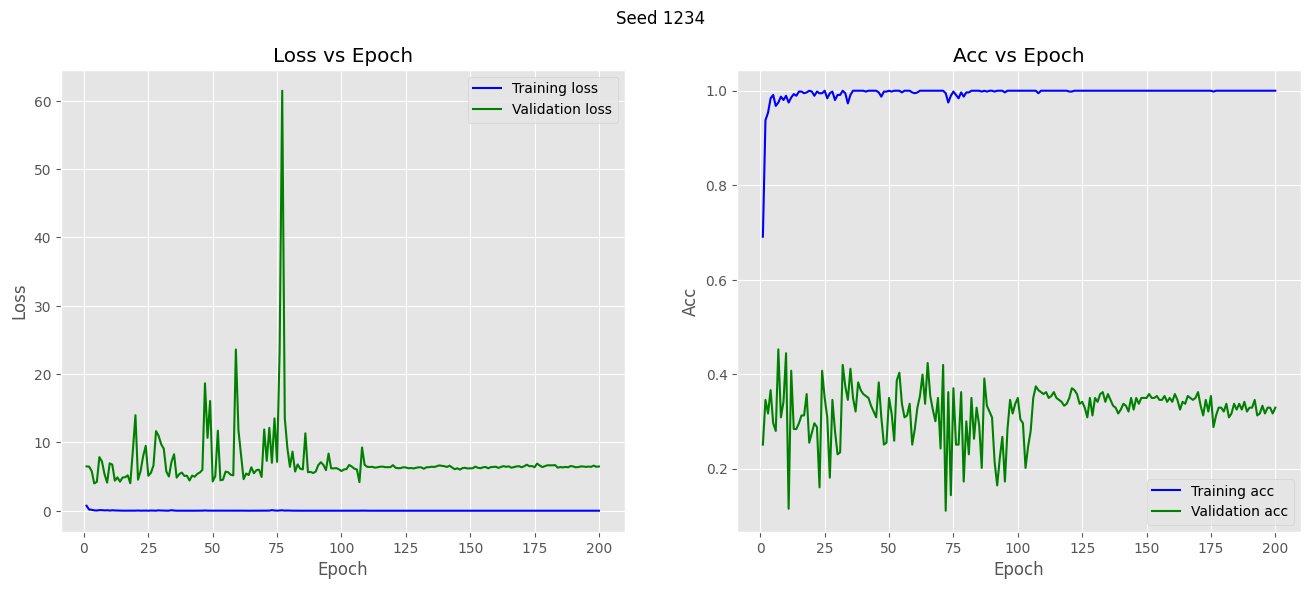

In [26]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [27]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    get_logits = get_logits_model('LPSLogitLayers')
    pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
    extras_model = {
        'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
        'conv1_stride': False,
        'maxpool_zpad': False,
        'swap_conv_pool': True,
        'inc_conv1_support': True,
        'apply_maxpool': True,
        'ret_prob': True,
        'forward_pool_method': 'LPS',
    }
    
    new_model = ResNet18Custom(
        input_shape=(3, 128, 128),
        num_classes=len(train_ds.class_to_idx),
        padding_mode='circular',
        pooling_layer=pooling_layer,
        extras_model=extras_model,
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/dso_data/new_data/wo_aug/rn18_seed{seed}_b16_theirmodel.pth"),
        map_location=device
    ))
    
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100*test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 32.9060
Evaluating Run 1: Seed 42
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 30.3419
Evaluating Run 2: Seed 100
[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)
Test Accuracy: 30.3419
Evaluating Run 3: Seed 123
[ResNet18Custom] self.maxpool_

[ResNet18Custom] self.maxpool_no_antialias: True
[ResNet18Custom] pooling_layer: functools.partial(<class 'layers.polydown.PolyphaseInvariantDown2D'>, component_selection=<class 'layers.polydown.LPS'>, get_logits=<class 'layers.lps_logit_layers.LPSLogitLayersV2'>)


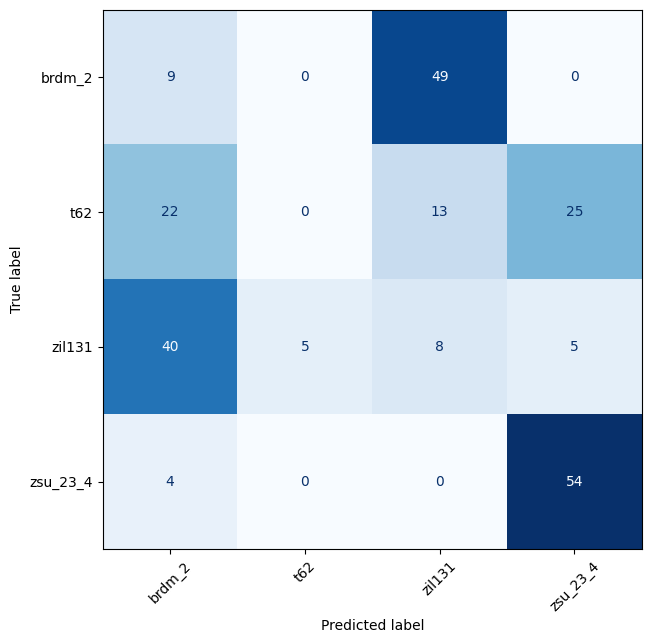

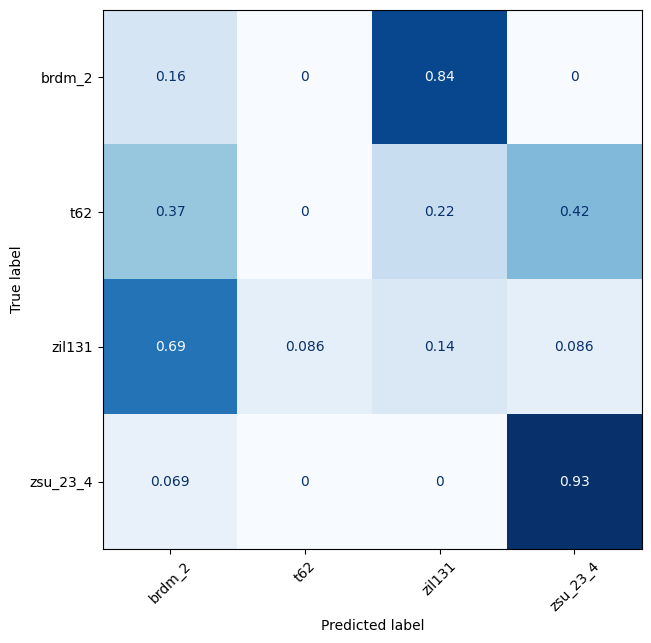

In [28]:
test_dataloader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 42
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

get_logits = get_logits_model('LPSLogitLayers')
pooling_layer = partial(PolyphaseInvariantDown2D, component_selection=LPS, get_logits=get_logits)
extras_model = {
    'logits_channels': {"maxpool": 8, "layer2": 16, "layer3": 32, "layer4": 64},
    'conv1_stride': False,
    'maxpool_zpad': False,
    'swap_conv_pool': True,
    'inc_conv1_support': True,
    'apply_maxpool': True,
    'ret_prob': True,
    'forward_pool_method': 'LPS',
}

new_model = ResNet18Custom(
    input_shape=(3, 128, 128),
    num_classes=len(train_ds.class_to_idx),
    padding_mode='circular',
    pooling_layer=pooling_layer,
    extras_model=extras_model,
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/dso_data/new_data/wo_aug/rn18_seed{seed}_b16_theirmodel.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        bs = inputs.size(0)
        labels_tensor[idx:idx+bs] = labels
        preds_tensor[idx:idx+bs] = preds
        idx += bs

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu = cp.asnumpy(cm)
disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
cm_norm_cpu = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()